In [ ]:
#bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm
import seaborn as sns

In [3]:
#Carregar dataset
path = "D:/OneDriveBackup/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/arquivos/projetos/projeto_conectividade/data/br_anatel_indice_brasileiro_conectividade_municipio.csv"
df = pd.read_csv(path, encoding='utf-8')

In [4]:

# Padronizar nome de colunas (lowercase)
df.columns = [c.strip().lower() for c in df.columns]

# Converter campos chave para numérico (coercivo)
for c in ['ano','ibc','cobertura_pop_4g5g','fibra','hhi_scm','hhi_smp','densidade_smp','densidade_scm','adensamento_erbs']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(df.dtypes)
print(df.head(3))


ano                       int64
sigla_uf                 object
id_municipio              int64
ibc                     float64
cobertura_pop_4g5g      float64
fibra                     int64
densidade_smp           float64
hhi_smp                   int64
densidade_scm           float64
hhi_scm                   int64
adensamento_estacoes    float64
dtype: object
    ano sigla_uf  id_municipio    ibc  cobertura_pop_4g5g  fibra  \
0  2024       RO       1100296  49.92             62.9831    100   
1  2024       AC       1200351  16.28             30.3470      0   
2  2024       AM       1300839  29.17             50.9133     50   

   densidade_smp  hhi_smp  densidade_scm  hhi_scm  adensamento_estacoes  
0          44.00       51          23.87       47                 25.39  
1          36.72       16           8.04       33                  8.36  
2          26.62        7           0.65       71                 17.47  


In [5]:
#Mostrar primeiras linhas
print("\nPrimeiras linhas do dataset:")
print(df.head())




Primeiras linhas do dataset:
    ano sigla_uf  id_municipio    ibc  cobertura_pop_4g5g  fibra  \
0  2024       RO       1100296  49.92             62.9831    100   
1  2024       AC       1200351  16.28             30.3470      0   
2  2024       AM       1300839  29.17             50.9133     50   
3  2024       AM       1302207  20.06             53.3310      0   
4  2024       PA       1501204  34.08             52.8200    100   

   densidade_smp  hhi_smp  densidade_scm  hhi_scm  adensamento_estacoes  
0          44.00       51          23.87       47                 25.39  
1          36.72       16           8.04       33                  8.36  
2          26.62        7           0.65       71                 17.47  
3          36.33       36           5.85       19                 13.45  
4          20.46       15           2.85       52                  6.26  


In [6]:

# === 3) Estatísticas gerais ===
print("\nResumo estatístico:")
print(df.describe())



Resumo estatístico:
                ano  id_municipio           ibc  cobertura_pop_4g5g  \
count  22280.000000  2.228000e+04  22280.000000        22280.000000   
mean    2022.500000  3.253591e+06     51.906346           80.004675   
std        1.118059  9.848440e+05     13.865064           18.047806   
min     2021.000000  1.100015e+06      9.810000            0.000000   
25%     2021.750000  2.512101e+06     43.140000           68.548075   
50%     2022.500000  3.146280e+06     54.310000           84.711650   
75%     2023.250000  4.119202e+06     62.292500           95.494500   
max     2024.000000  5.300108e+06     94.570000          120.030900   

              fibra  densidade_smp       hhi_smp  densidade_scm       hhi_scm  \
count  22280.000000   22280.000000  22280.000000   22280.000000  22280.000000   
mean      76.216338      59.923873     47.390619      16.617638     56.186131   
std       40.896435      19.343919     25.059560      17.417516     20.941347   
min        0.00

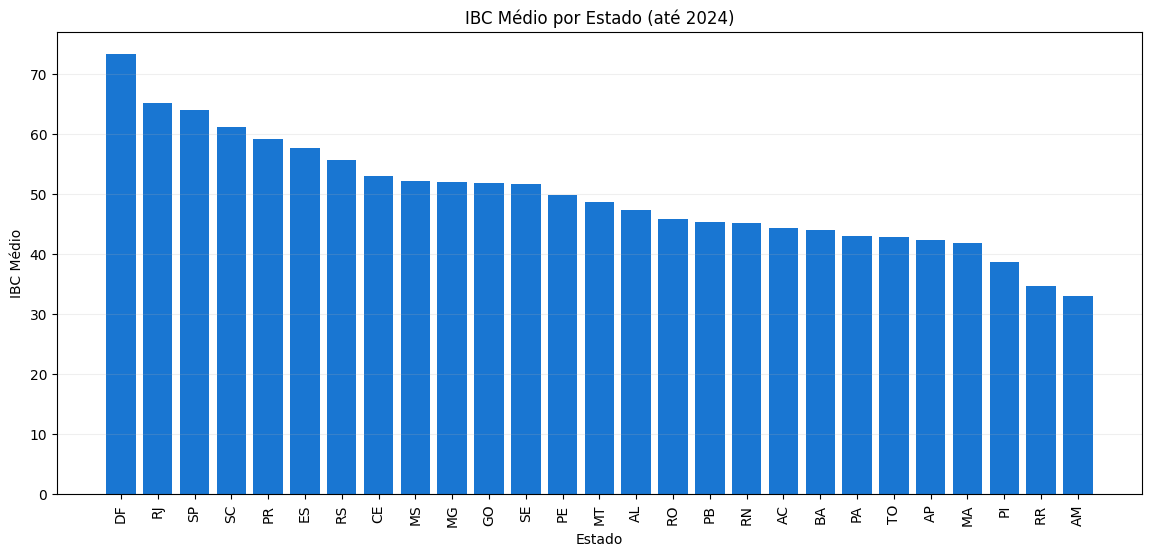

In [7]:
#IBC por estado (média)
if {'sigla_uf','ibc'}.issubset(df.columns):
    df_estado = (df.groupby("sigla_uf", as_index=False)["ibc"]
                   .mean()
                   .sort_values("ibc", ascending=False))

    plt.figure(figsize=(14,6))
    plt.bar(df_estado["sigla_uf"], df_estado["ibc"], color="#1976d2")
    plt.title(f"IBC Médio por Estado (até {int(df['ano'].max())})")
    plt.xlabel("Estado")
    plt.ylabel("IBC Médio")
    plt.xticks(rotation=90)
    plt.grid(True, axis='y', alpha=0.2)
    plt.show()


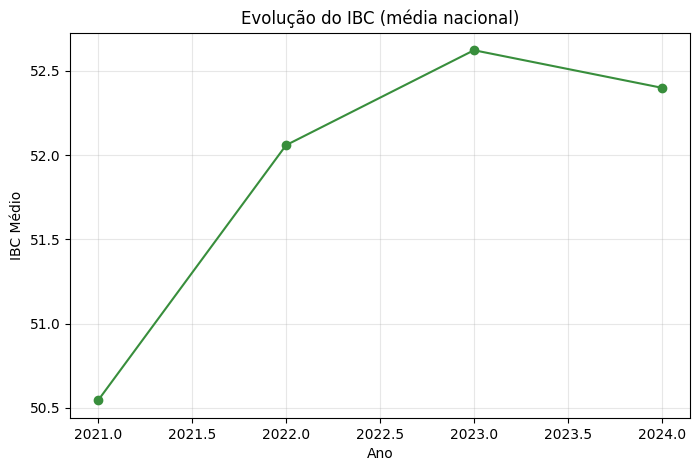

In [8]:
#Evolução do IBC ao longo dos anos

if {'ano','ibc'}.issubset(df.columns):
    df_ano = df.groupby("ano", as_index=False)["ibc"].mean().sort_values("ano")

    plt.figure(figsize=(8,5))
    plt.plot(df_ano["ano"], df_ano["ibc"], marker="o", color="#388e3c")
    plt.title("Evolução do IBC (média nacional)")
    plt.xlabel("Ano")
    plt.ylabel("IBC Médio")
    plt.grid(True, alpha=0.3)
    plt.show()


In [9]:
#Scatter renda x conectividade (exemplo com fibra)

if {'fibra','ibc','sigla_uf'}.issubset(df.columns):
    fig = px.scatter(
        df, x="fibra", y="ibc",
        color="sigla_uf",
        trendline="ols",  # linha de tendência
        title="Relação entre Presença de Fibra (0–100) e IBC"
    )
    fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="right", x=1))
    fig.show()



In [10]:
#Municípios prioritários para expansão de backhaul
#Baixa fibra & alta cobertura móvel → prioridade fixa
TH_LOW_FIBRA = 33        # baixa presença de backhaul (0–100)
TH_HIGH_COB = 80         # alta cobertura 4G/5G (% moradores cobertos)

mask = (df['fibra'] <= TH_LOW_FIBRA) & (df['cobertura_pop_4g5g'] >= TH_HIGH_COB)
prior_mun = (df[mask]
             .copy()
             .sort_values(['cobertura_pop_4g5g','ibc'], ascending=[False, True]))

cols_show = ['id_municipio','nome_municipio','sigla_uf','fibra','cobertura_pop_4g5g','ibc']


In [11]:
#HHI alto → IBC baixo (teste por UF)
# Agregar HHI (SCM e SMP) e IBC por UF:
need = {'sigla_uf','ibc','hhi_scm','hhi_smp'}
if need.issubset(df.columns):
    uf = (df.groupby('sigla_uf', as_index=False)
            .agg(ibc_uf=('ibc','mean'),
                 hhi_scm_uf=('hhi_scm','mean'),
                 hhi_smp_uf=('hhi_smp','mean')))

    corr_scm = uf['ibc_uf'].corr(uf['hhi_scm_uf'])
    corr_smp = uf['ibc_uf'].corr(uf['hhi_smp_uf'])
    print(f"Correlação IBC (UF) x HHI_SCM: {corr_scm:.2f} | IBC x HHI_SMP: {corr_smp:.2f}")

    # Visual: scatter com tendência
    import plotly.express as px
    fig1 = px.scatter(uf, x='hhi_scm_uf', y='ibc_uf', trendline='ols', title='IBC vs HHI (SCM) por UF')
    fig2 = px.scatter(uf, x='hhi_smp_uf', y='ibc_uf', trendline='ols', title='IBC vs HHI (SMP) por UF')
    fig1.show(); fig2.show()


Correlação IBC (UF) x HHI_SCM: 0.48 | IBC x HHI_SMP: 0.61


In [12]:
#IBC por região
#
uf_to_reg = {'AC':'N','AL':'NE','AM':'N','AP':'N','BA':'NE','CE':'NE','DF':'CO','ES':'SE','GO':'CO','MA':'NE','MT':'CO','MS':'CO','MG':'SE','PA':'N','PB':'NE','PR':'S','PE':'NE','PI':'NE','RJ':'SE','RN':'NE','RO':'N','RR':'N','RS':'S','SC':'S','SE':'NE','SP':'SE','TO':'N'}

uf_ibc = df.groupby('sigla_uf', as_index=False)['ibc'].mean()
uf_ibc['regiao'] = uf_ibc['sigla_uf'].map(uf_to_reg)
print(uf_ibc.groupby('regiao')['ibc'].mean().sort_values())

uf_to_reg = {'AC':'N','AL':'NE','AM':'N','AP':'N','BA':'NE','CE':'NE','DF':'CO','ES':'SE','GO':'CO','MA':'NE','MT':'CO','MS':'CO','MG':'SE','PA':'N','PB':'NE','PR':'S','PE':'NE','PI':'NE','RJ':'SE','RN':'NE','RO':'N','RR':'N','RS':'S','SC':'S','SE':'NE','SP':'SE','TO':'N'}

uf_ibc = df.groupby('sigla_uf', as_index=False)['ibc'].mean()
uf_ibc['regiao'] = uf_ibc['sigla_uf'].map(uf_to_reg)
print(uf_ibc.groupby('regiao')['ibc'].mean().sort_values())


regiao
N     40.831732
NE    46.287079
CO    56.445695
S     58.610945
SE    59.671335
Name: ibc, dtype: float64
regiao
N     40.831732
NE    46.287079
CO    56.445695
S     58.610945
SE    59.671335
Name: ibc, dtype: float64
